# H-calls4famPlusPCA

call4fam Cluster and Classification w/ or wo PCA

## Data Table

In [1]:
# @title
import datetime
print(datetime.datetime.now())

2025-03-28 01:16:56.507900


Here are some samples of malware call sequences.

Although we actually know the dataset contains four malware families (as shown in the name of sub-directory), for some questions in this homework, you should pretend you have no idea what malware family a sample belongs to.

In [2]:
import pandas as pd
import numpy as np

In [3]:
# get data from github

import requests

url = 'https://github.com/hsiaom26/DS4CS-24/raw/main/data/calls4fam_0522_tfds.tgz'

response = requests.get(url)

if response.status_code == 200:
    # Open the file for writing
    with open('calls4fam_0522_tfds.tgz', 'wb') as f:
        # Write the response content to the file
        f.write(response.content)
else:
    print('Error: Failed to download the file')

In [ ]:
!tar -zxvf calls4fam_0522_tfds.tgz

In [5]:
!ls -al calls4fam_0522

total 56
drwxr-xr-x 6 root root  4096 Feb 21  2024 .
drwxr-xr-x 1 root root  4096 Mar 28 01:17 ..
drwxr-xr-x 2 root root 12288 Feb 21  2024 0
drwxr-xr-x 2 root root 12288 Feb 21  2024 1
drwxr-xr-x 2 root root 12288 Feb 21  2024 2
drwxr-xr-x 2 root root 12288 Feb 21  2024 5


In [6]:
def count_api_calls(malware_text_file):
  aip_dict = dict()
  with open(malware_text_file, 'r') as file:
    call_seq = file.readline() # note: only one line in .txt file
    calls = call_seq.split()
    for call in calls:
      if call in aip_dict:
        aip_dict[call] += 1
      else:
        aip_dict[call] = 1
    return aip_dict

In [7]:
import os
# A dictionary to collect all count_api_calls() returns
malware_call_dict = dict()

# Define the root directory to walk through
root_dir = "/content/calls4fam_0522/"

# Walk through the directory and its subdirectories
for dir_name, subdir_list, file_list in os.walk(root_dir):

    # Read all .txt files in the current directory
    for file_name in file_list:
        if file_name.endswith(".txt"):
            # Read the file contents
            subdir = dir_name.split('/')[-1]
            malware_call_dict[subdir+'/'+file_name] = count_api_calls(os.path.join(dir_name, file_name))

In [8]:
import pandas as pd

# Convert the dictionary to a DataFrame
# it contains all the api call infomation about all malware samples
# the number in each cell is the call frequency of a specific malware on a specific api
malware_call_df = pd.DataFrame.from_dict(malware_call_dict, orient='index')
malware_call_df.fillna(0, inplace=True)
malware_call_df

,execve,mmap2,cacheflush,readlink,mprotect,brk,open,close,munmap,set_tls,...,getegid32,getgid32,accept,statfs64,_llseek,fchown32,sysinfo,lstat64,fchown,fchmodat
2/650.txt,1.0,5.0,7.0,1.0,2.0,5.0,1.0,2.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2/712.txt,1.0,5.0,7.0,1.0,2.0,5.0,1.0,2.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2/762.txt,1.0,5.0,7.0,1.0,2.0,5.0,1.0,2.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2/654.txt,1.0,5.0,7.0,1.0,2.0,5.0,1.0,2.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2/658.txt,1.0,5.0,7.0,1.0,2.0,5.0,1.0,2.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5/1020.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5/938.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1/580.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1/397.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# we convert the call frequency in each cell to a binary value indicating either
# the malware sample call this api or not
malware_binary_call_df = malware_call_df.applymap(lambda x: 1.0 if x > 0.0 else 0.0)
malware_binary_call_df

<ipython-input-9-7948dc8f8da0>:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  malware_binary_call_df = malware_call_df.applymap(lambda x: 1.0 if x > 0.0 else 0.0)


,execve,mmap2,cacheflush,readlink,mprotect,brk,open,close,munmap,set_tls,...,getegid32,getgid32,accept,statfs64,_llseek,fchown32,sysinfo,lstat64,fchown,fchmodat
2/650.txt,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2/712.txt,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2/762.txt,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2/654.txt,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2/658.txt,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5/1020.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5/938.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1/580.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1/397.txt,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Q1

Now, your turn. Try K-means in Q1. You may use either `malware_call_df` or `malware_binary_call_df`.


### Q1-1

Writre code to apply K-means, use `euclidean` to evaluate distance. Show the Elbow Plot with avgWithinSS. You do not really need to use the python package shown below. You may use any packages you are familiar with.

In [10]:
import numpy as np
from scipy.cluster.vq import kmeans,vq
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

X = malware_binary_call_df.values

##### cluster data into K=1..20 clusters #####
K = range(1,20)

#### add your code here!

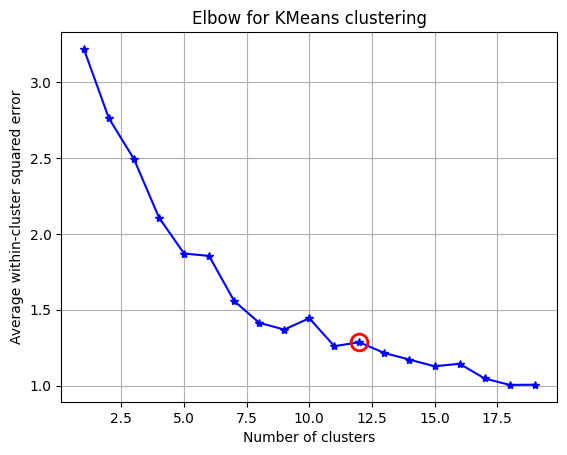

In [11]:
##### plot ###


### Q1-2

How many clusters do you suggest by referencing the elbow plot? Why?

### Q1-3

Show how many samples are there in each cluster? Is there any cluster which has only a few samples?

,count
1,225
10,169
0,138
5,129
9,107
4,98
8,97
6,96
7,88
3,46


### Q1-4

`malware_call_df` is better or `malware_binary_call_df` is better to represent the data? (open question)


### Q1-5

what if we use some normalization or standardzation on `malware_call_df`? Would it be better to represent the data? (open question)

## Q2

Use UPGMA to visualized the data. You may sample the dataset for better visualization (lets say 10% sample in each class).

### Q2-1

Plot UPGMA using 10% data

In [ ]:
import scipy
import scipy.cluster.hierarchy as sch
import matplotlib.pylab as plt

from scipy.spatial.distance import squareform, pdist

In [ ]:
malware_binary_call_10_df = malware_binary_call_df.sample(frac=0.1)
malware_binary_call_10_df

,execve,mmap2,cacheflush,readlink,mprotect,brk,open,close,munmap,set_tls,...,getegid32,getgid32,accept,statfs64,_llseek,fchown32,sysinfo,lstat64,fchown,fchmodat
2/694.txt,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5/926.txt,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0/123.txt,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5/921.txt,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0/90.txt,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2/667.txt,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1/336.txt,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5/1185.txt,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0/209.txt,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0


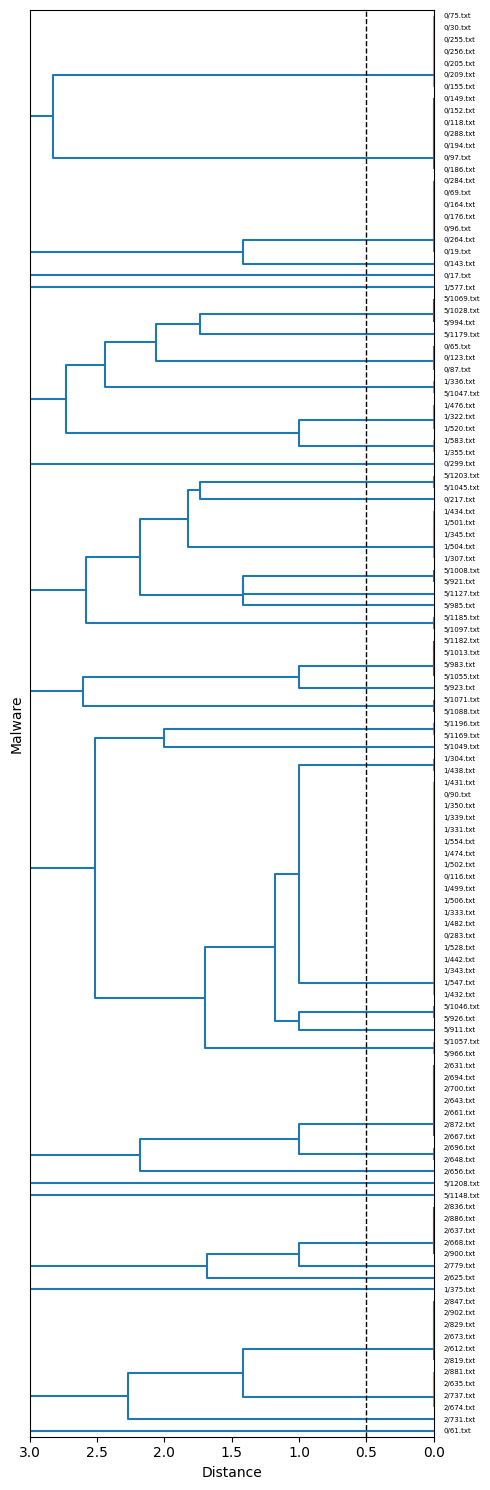

In [ ]:
# use binary features and euclidean distance
# and perform UPGMA

### Q2-2
Try to use jaccard distance in UPGMA.

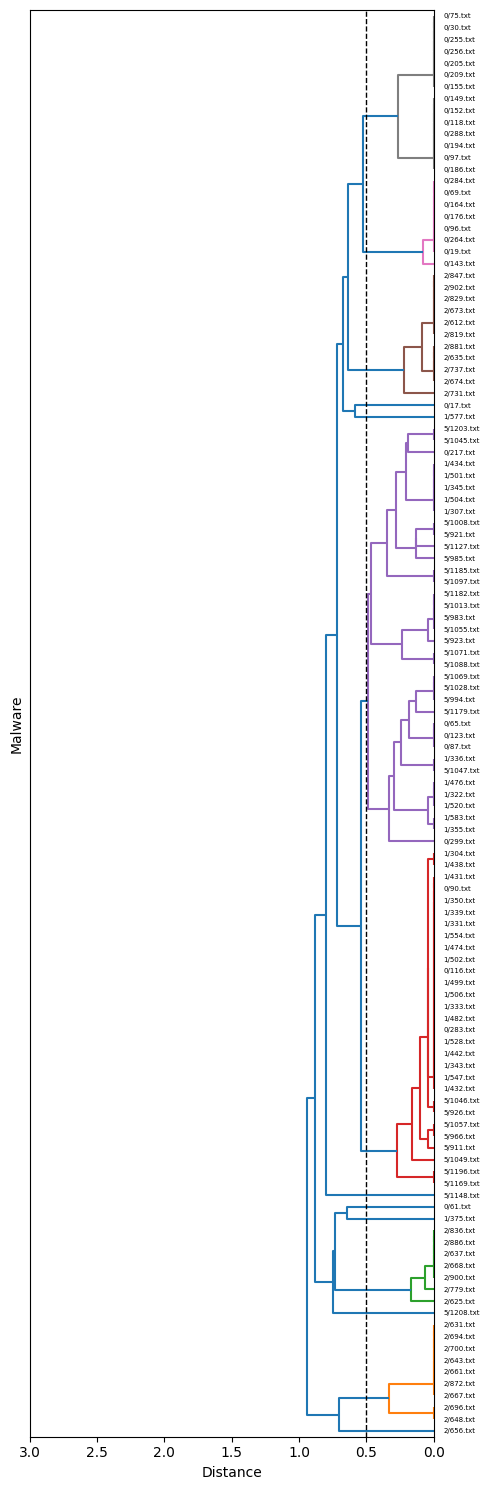

In [ ]:
# use binary features
# and UPGMA

### Q2-2

Jaccard looks better. Why?

## Q3

### Q3-1

Try K-Means with k = 4, and compare the dbscan result with the actual class lable shown in the file name.


In [ ]:
from sklearn.cluster import KMeans

X = malware_call_df.values

## your code

In [ ]:
compare_df

,labels_true,cluster_label
0,2,0
1,2,0
2,2,0
3,2,0
4,2,0
...,...,...
1203,5,0
1204,5,0
1205,1,0
1206,1,0


### Q3-2

The cluster k=4 looks not good. How can you improve it?

## Q4

Now, you can output the `malware_call_df` as a csv file, and analyze it in Orange or any other tools (or simply use colab).

In [ ]:
output_df = malware_call_df.copy()
output_df['target'] = malware_call_df.index.str.split('/').str[0]
output_df.to_csv('malware_call_df.csv')

### Q4-1

What is the best classificaiton rate (accuracy) you can find? What algorithm is it? You do not need to post the Orange workflow in this ipynb. Posting the result is good enough. If you use tensorflow, show us the results.

### Q4-2

Guess why the alogithim performs best? (open question)

## Q5

Lets try PCA!


### Q5-1

Apply PCA on the data, and only use 3 principles.

 *  plot the variance of each PCA
 * plot PCAed data in 3D spcae

In [ ]:
from sklearn import decomposition

X = malware_call_df
y = output_df['target']

# your code?

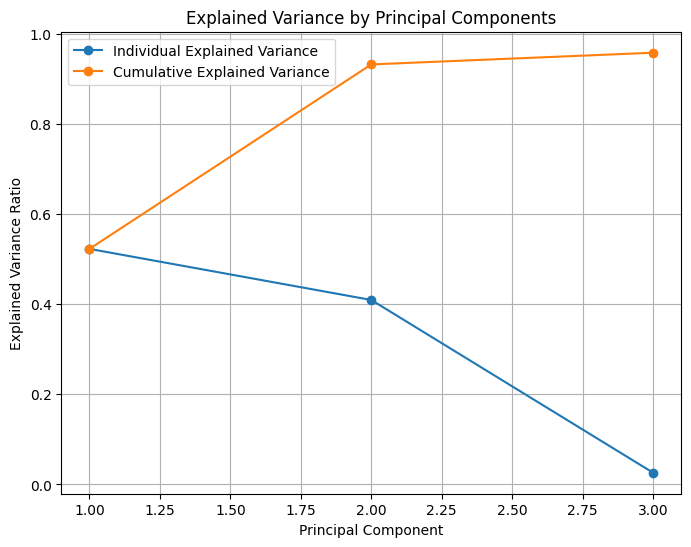

In [ ]:
import plotly.express as px

### Q5-2

Does PCAed data perform better (w.r.t accuracy rate) than original data?